# Ken French Data Library - Fama-French 25 Portfolios

This notebook provides summary statistics and visualizations for the Fama-French 25 portfolios
sorted by Size and various characteristics (Book-to-Market, Operating Profitability, Investment).

## Data Source

Data is publicly available from [Ken French's Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html).

## Reference

Fama, Eugene F., and Kenneth R. French. "The cross-section of expected stock returns."
The Journal of Finance 47.2 (1992): 427-465.

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import chartbook

BASE_DIR = chartbook.env.get_project_root()
DATA_DIR = BASE_DIR / "_data"

warnings.filterwarnings("ignore")

## Load the Datasets

We have three daily portfolio datasets:
1. **Size x Book-to-Market**: 25 portfolios sorted by size and B/M ratio
2. **Size x Operating Profitability**: 25 portfolios sorted by size and OP
3. **Size x Investment**: 25 portfolios sorted by size and investment

In [2]:
# Load Size x Book-to-Market portfolios
size_bm_df = pd.read_parquet(DATA_DIR / "ftsfr_french_portfolios_25_daily_size_and_bm.parquet")
print(f"Size x Book-to-Market shape: {size_bm_df.shape}")
size_bm_df.head()

Size x Book-to-Market shape: (653225, 3)


,unique_id,ds,y
0,SMALL LoBM,1926-07-01,-0.0046
1,SMALL LoBM,1926-07-02,0.0057
2,SMALL LoBM,1926-07-06,0.0038
3,SMALL LoBM,1926-07-07,-0.0081
4,SMALL LoBM,1926-07-08,0.0056


In [3]:
# Load Size x Operating Profitability portfolios
size_op_df = pd.read_parquet(DATA_DIR / "ftsfr_french_portfolios_25_daily_size_and_op.parquet")
print(f"Size x Operating Profitability shape: {size_op_df.shape}")
size_op_df.head()

Size x Operating Profitability shape: (392725, 3)


,unique_id,ds,y
0,SMALL LoOP,1963-07-01,-0.0070
1,SMALL LoOP,1963-07-02,0.0033
2,SMALL LoOP,1963-07-03,0.0067
3,SMALL LoOP,1963-07-05,0.0052
4,SMALL LoOP,1963-07-08,-0.0031


In [4]:
# Load Size x Investment portfolios
size_inv_df = pd.read_parquet(DATA_DIR / "ftsfr_french_portfolios_25_daily_size_and_inv.parquet")
print(f"Size x Investment shape: {size_inv_df.shape}")
size_inv_df.head()

Size x Investment shape: (392725, 3)


,unique_id,ds,y
0,SMALL LoINV,1963-07-01,-0.0067
1,SMALL LoINV,1963-07-02,0.0039
2,SMALL LoINV,1963-07-03,0.0034
3,SMALL LoINV,1963-07-05,0.0072
4,SMALL LoINV,1963-07-08,-0.0021


## Summary Statistics - Size x Book-to-Market Portfolios

In [5]:
# Pivot to wide format
size_bm_wide = size_bm_df.pivot(index='ds', columns='unique_id', values='y')

# Calculate summary statistics (annualized)
summary_stats = size_bm_wide.describe().T
summary_stats['annualized_mean'] = summary_stats['mean'] * 252
summary_stats['annualized_std'] = summary_stats['std'] * (252 ** 0.5)
summary_stats['sharpe'] = summary_stats['annualized_mean'] / summary_stats['annualized_std']
summary_stats[['count', 'annualized_mean', 'annualized_std', 'sharpe', 'min', 'max']]

,count,annualized_mean,annualized_std,sharpe,min,max
unique_id,,,,,,
BIG HiBM,26129.0,0.142705,0.280692,0.508405,-0.1815,0.2397
BIG LoBM,26129.0,0.110707,0.182019,0.608216,-0.1845,0.1359
ME1 BM2,26129.0,0.107540,0.309830,0.347092,-0.2693,0.4579
ME1 BM3,26129.0,0.130829,0.238188,0.549267,-0.1980,0.3711
ME1 BM4,26129.0,0.147271,0.214402,0.686890,-0.1459,0.2451
ME2 BM1,26129.0,0.098051,0.238048,0.411897,-0.1546,0.2821
ME2 BM2,26129.0,0.128415,0.202870,0.632992,-0.1344,0.3101
ME2 BM3,26129.0,0.133210,0.196182,0.679012,-0.1471,0.1903
ME2 BM4,26129.0,0.139985,0.200609,0.697803,-0.1544,0.2991


## Data Coverage

Let's examine the date range and data availability.

In [6]:
# Data coverage
print("Size x Book-to-Market Portfolios:")
print(f"  Date range: {size_bm_wide.index.min()} to {size_bm_wide.index.max()}")
print(f"  Number of trading days: {len(size_bm_wide)}")
print(f"  Number of portfolios: {len(size_bm_wide.columns)}")

Size x Book-to-Market Portfolios:
  Date range: 1926-07-01 00:00:00 to 2025-11-28 00:00:00
  Number of trading days: 26129
  Number of portfolios: 25


## Cumulative Returns - Size x Book-to-Market Portfolios

Let's visualize the cumulative returns for a selection of portfolios.

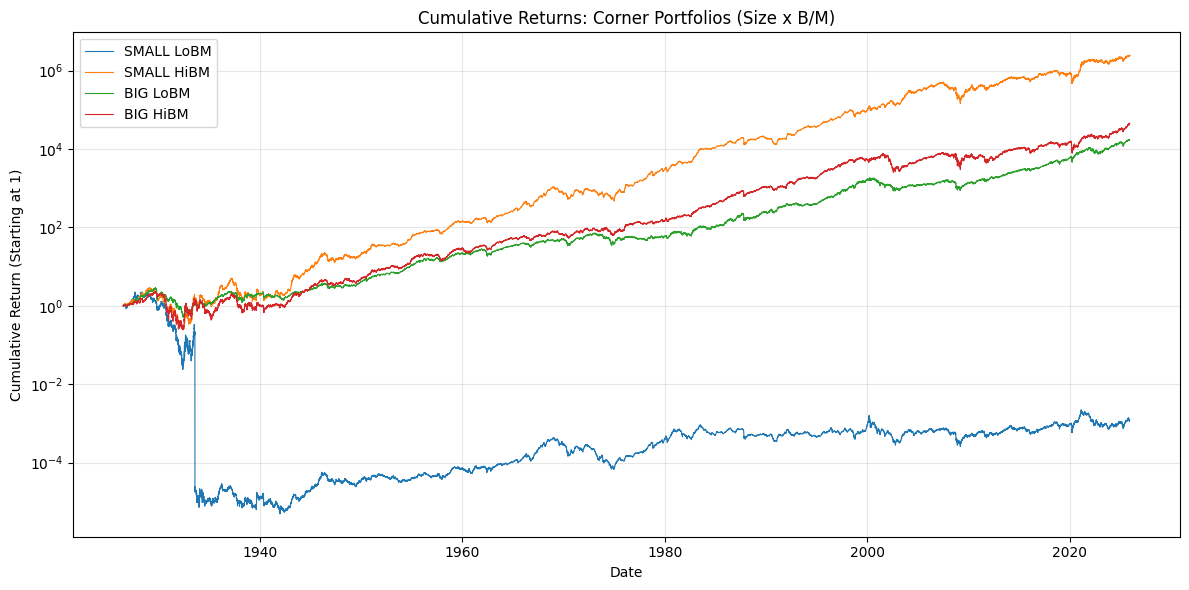

In [7]:
# Select corner portfolios for visualization
corner_portfolios = ['SMALL LoBM', 'SMALL HiBM', 'BIG LoBM', 'BIG HiBM']
available_corners = [p for p in corner_portfolios if p in size_bm_wide.columns]

if available_corners:
    fig, ax = plt.subplots(figsize=(12, 6))

    for portfolio in available_corners:
        cumret = (1 + size_bm_wide[portfolio]).cumprod()
        ax.plot(cumret.index, cumret.values, label=portfolio, linewidth=0.8)

    ax.set_title('Cumulative Returns: Corner Portfolios (Size x B/M)', fontsize=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return (Starting at 1)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    plt.tight_layout()
    plt.show()
else:
    print("Corner portfolios not found. Available portfolios:", size_bm_wide.columns.tolist()[:5])

## Correlation Matrix - Size x Book-to-Market Portfolios

Showing correlation between a subset of portfolios.

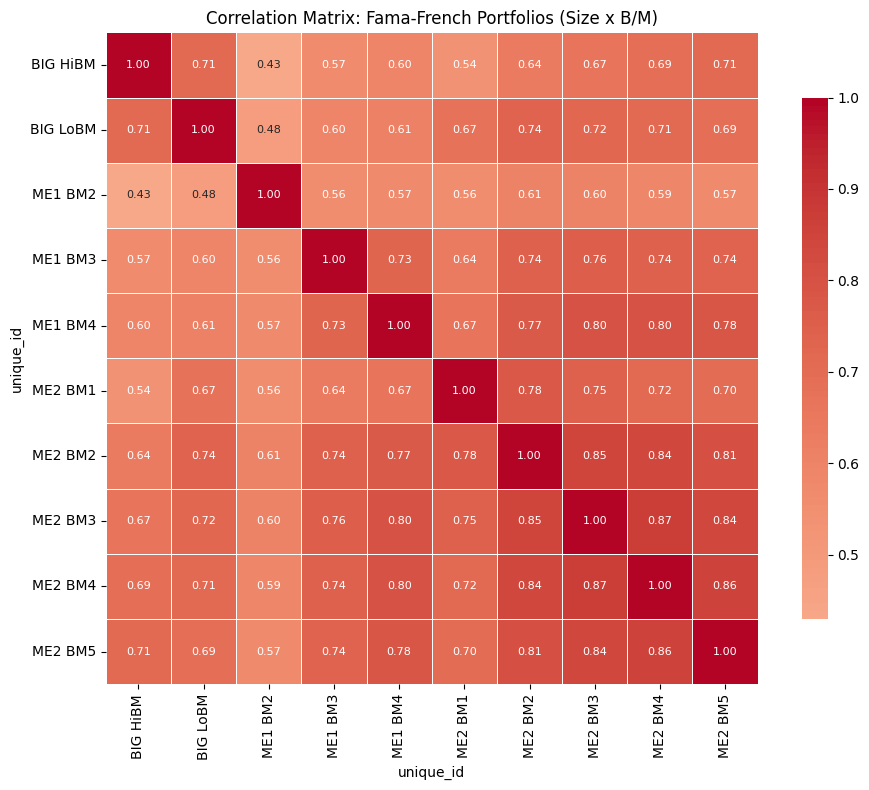

In [8]:
# Calculate correlation matrix for subset
n_portfolios = min(10, len(size_bm_wide.columns))
subset_cols = size_bm_wide.columns[:n_portfolios]
corr_matrix = size_bm_wide[subset_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)
plt.title('Correlation Matrix: Fama-French Portfolios (Size x B/M)', fontsize=12)
plt.tight_layout()
plt.show()

## Distribution of Daily Returns

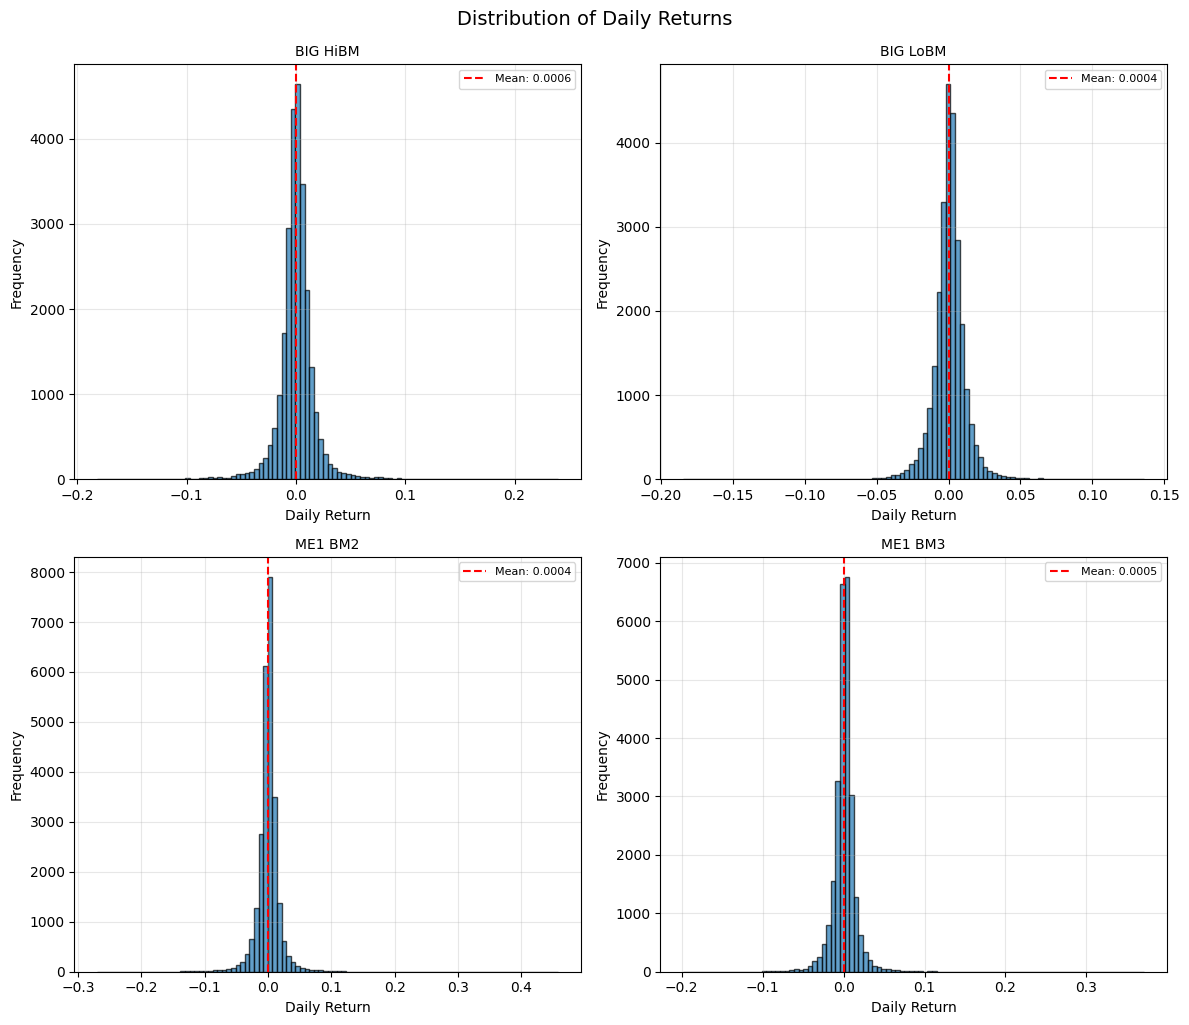

In [9]:
# Histogram of daily returns for a few portfolios
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

portfolios_to_plot = size_bm_wide.columns[:4].tolist()
for i, portfolio in enumerate(portfolios_to_plot):
    ax = axes[i]
    size_bm_wide[portfolio].hist(ax=ax, bins=100, edgecolor='black', alpha=0.7)
    mean_ret = size_bm_wide[portfolio].mean()
    ax.axvline(mean_ret, color='red', linestyle='--', label=f'Mean: {mean_ret:.4f}')
    ax.set_title(f'{portfolio}', fontsize=10)
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Distribution of Daily Returns', y=1.02, fontsize=14)
plt.show()

## Summary

This dataset provides daily returns for the Fama-French 25 portfolios formed on various
characteristics. These portfolios are widely used as test assets in empirical asset pricing
research to evaluate factor models and understand the cross-section of expected returns.

The portfolios exhibit significant variation in average returns across size and value dimensions,
consistent with the well-documented size and value premiums in equity markets.